In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!unzip -q "/content/drive/MyDrive/archive (2).zip" -d "/content/plantvillage dataset"


In [ ]:
import os
import json
from zipfile import ZipFile
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers,models
from sklearn.model_selection import train_test_split
import matplotlib.image as mpimg
import random
random.seed(0)
tf.random.set_seed(0)
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Checking the classes of  plants
print(len(os.listdir("plantvillage dataset/color")))
print(os.listdir("plantvillage dataset/color")[:5])

38
['Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Septoria_leaf_spot', 'Apple___Apple_scab', 'Strawberry___healthy', 'Corn_(maize)___healthy']


In [ ]:
# Checking the no. of plant images in Peach_healthy class of a plant
print(len(os.listdir("plantvillage dataset/color/Peach___healthy")))
print(os.listdir("plantvillage dataset/color/Peach___healthy")[:5])

360
['889676f3-e37b-4b86-a440-c087611e5cd5___Rutg._HL 2432.JPG', '96e5f242-6797-4564-897f-de3619bde240___Rutg._HL 3508.JPG', 'fe3bc54d-4164-4fea-a0bd-d96299ab3422___Rutg._HL 3578.JPG', '5d994e9c-adc0-47c6-bc59-b4ec117b070e___Rutg._HL 3669.JPG', 'eccf6b29-5909-4b84-83b2-4dd3a6a5745d___Rutg._HL 2436.JPG']


In [ ]:
# Dataset Path
base_dir = "plantvillage dataset/color"

(256, 256, 3)
[[[167 163 196]
  [166 162 195]
  [165 161 194]
  ...
  [185 182 211]
  [183 180 209]
  [181 178 207]]

 [[170 166 199]
  [169 165 198]
  [168 164 197]
  ...
  [186 183 212]
  [184 181 210]
  [183 180 209]]

 [[170 166 199]
  [169 165 198]
  [168 164 197]
  ...
  [188 185 214]
  [186 183 212]
  [185 182 211]]

 ...

 [[100  90 124]
  [102  92 126]
  [104  94 128]
  ...
  [126 110 137]
  [126 110 137]
  [126 110 137]]

 [[101  91 125]
  [102  92 126]
  [103  93 127]
  ...
  [122 106 133]
  [123 107 134]
  [123 107 134]]

 [[104  94 128]
  [103  93 127]
  [102  92 126]
  ...
  [121 105 132]
  [122 106 133]
  [123 107 134]]]


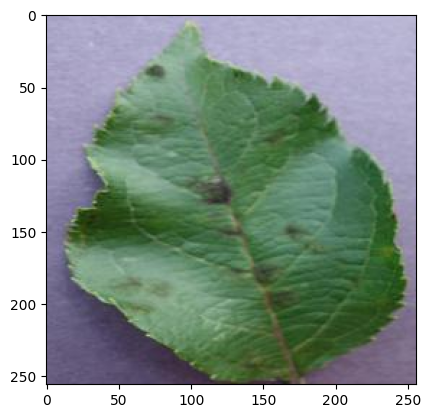

In [ ]:
# Displaying the image and shape of the image
image_path = "/content/plantvillage dataset/color/Apple___Apple_scab/00075aa8-d81a-4184-8541-b692b78d398a___FREC_Scab 3335.JPG"

# Path Reading and image showing
img = mpimg.imread(image_path)
print(img.shape)
print(img)
plt.imshow(img)

In [ ]:
# Parameters of image
img_size = 224
batch_size = 32

In [ ]:
# Image Data Generators
data_gen = ImageDataGenerator(
    rescale = 1./255,
    validation_split = 0.2,
    #rotation_range = 20,
    #width_shift_range = 0.2,
    #height_shift_range = 0.2,
    #shear_range = 0.2,
    #zoom_range = 0.2,
    #horizontal_flip = True,
)

In [ ]:
# Train Generator
train_gen = data_gen.flow_from_directory(
    base_dir,
    target_size = (img_size,img_size),
    batch_size = batch_size,
    subset="training",
    class_mode="categorical"
)

Found 43456 images belonging to 38 classes.


In [ ]:
# Validation Generator
validation_gen = data_gen.flow_from_directory(
    base_dir,
    target_size = (img_size,img_size),
    batch_size = batch_size,
    subset="validation",
    class_mode="categorical"
)

Found 10849 images belonging to 38 classes.


In [ ]:
model = models.Sequential()

model.add(layers.Conv2D(32,(3,3),activation="relu",input_shape=(img_size,img_size,3)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64,(3,3),activation="relu"))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Flatten())
model.add(layers.Dense(256,activation="relu"))
model.add(layers.Dense(train_gen.num_classes,activation="softmax"))

# Compiling the model
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    47,776,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,805,158 (182.36 MB)

 Trainable params: 47,805,158 (182.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
final_model = model.fit(
    train_gen,
    steps_per_epoch = train_gen.samples // batch_size,
    epochs = 6,
    validation_data = validation_gen,
    validation_steps = validation_gen.samples // batch_size
)


Epoch 1/6
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 75s 49ms/step - accuracy: 0.5968 - loss: 1.7266 - val_accuracy: 0.8654 - val_loss: 0.4433
Epoch 2/6
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 66s 49ms/step - accuracy: 0.9193 - loss: 0.2553 - val_accuracy: 0.8826 - val_loss: 0.3830
Epoch 3/6
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 67s 49ms/step - accuracy: 0.9662 - loss: 0.1044 - val_accuracy: 0.8593 - val_loss: 0.5373
Epoch 4/6
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 65s 48ms/step - accuracy: 0.9769 - loss: 0.0731 - val_accuracy: 0.8668 - val_loss: 0.5783
Epoch 5/6
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 66s 48ms/step - accuracy: 0.9852 - loss: 0.0481 - val_accuracy: 0.8446 - val_loss: 0.7148
Epoch 6/6
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 65s 48ms/step - accuracy: 0.9810 - loss: 0.0587 - val_accuracy: 0.8786 - val_loss: 0.6229


In [ ]:
val_loss,val_acc = model.evaluate(validation_gen,steps = validation_gen.samples // batch_size)
print("Validation Loss: ",val_loss)
print("Validation Accuracy: ",val_acc)

339/339 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.8819 - loss: 0.6139
Validation Loss:  0.6229263544082642
Validation Accuracy:  0.8785951137542725


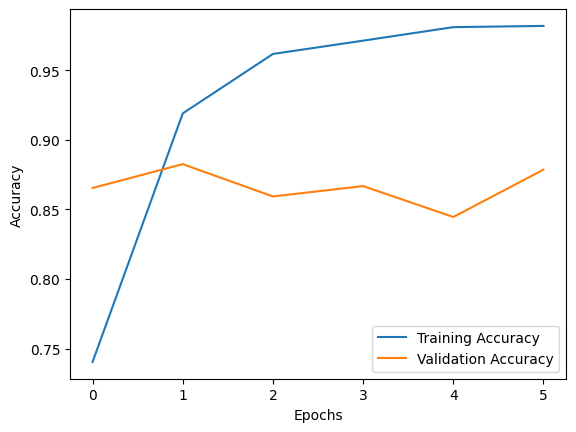

In [ ]:
# Plotting Training and Validation Accuracy Values
plt.plot(final_model.history["accuracy"],label="Training Accuracy")
plt.plot(final_model.history["val_accuracy"],label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_size,img_size,3))
base_model.trainable = False  # Freeze pretrained layers

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(train_gen.num_classes, activation='softmax')(x)

transfer_model = Model(inputs=base_model.input, outputs=predictions)
transfer_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
final_model = transfer_model.fit(
    train_gen,
    steps_per_epoch = train_gen.samples // batch_size,
    epochs = 6,
    validation_data = validation_gen,
    validation_steps = validation_gen.samples // batch_size
)

Epoch 1/6
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 100s 55ms/step - accuracy: 0.7106 - loss: 1.0572 - val_accuracy: 0.9318 - val_loss: 0.2123
Epoch 2/6
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 68s 50ms/step - accuracy: 0.8961 - loss: 0.3109 - val_accuracy: 0.9447 - val_loss: 0.1707
Epoch 3/6
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 67s 49ms/step - accuracy: 0.9172 - loss: 0.2500 - val_accuracy: 0.9399 - val_loss: 0.1714
Epoch 4/6
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 68s 50ms/step - accuracy: 0.9239 - loss: 0.2202 - val_accuracy: 0.9469 - val_loss: 0.1540
Epoch 5/6
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 67s 49ms/step - accuracy: 0.9325 - loss: 0.2042 - val_accuracy: 0.9513 - val_loss: 0.1403
Epoch 6/6
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 68s 50ms/step - accuracy: 0.9360 - loss: 0.1941 - val_accuracy: 0.9545 - val_loss: 0.1337


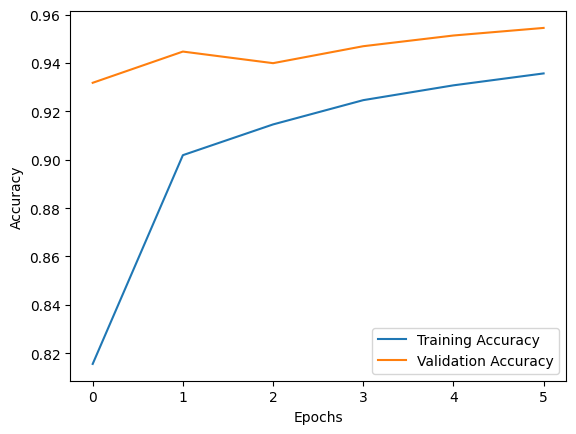

In [ ]:
# Plotting Training and Validation Accuracy Values
plt.plot(final_model.history["accuracy"],label="Training Accuracy")
plt.plot(final_model.history["val_accuracy"],label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
# Function to load and Preprocess the Image using Pillow
def load_and_preprocess_image(image_path,target_size=(224,224)):
  # Image Loading
  img = Image.open(image_path)
  img = img.resize(target_size)
  # Converting the image into a numy array
  img_array = np.array(img)
  img_array = np.expand_dims(img_array,axis=0)
  # Scaling of image Values
  img_array = img_array / 255.
  return img_array



In [ ]:
# Function to predict the class of an image
def predict_class(model,image_path,class_indices):
  img_array = load_and_preprocess_image(image_path=image_path)
  predictions = transfer_model.predict(img_array)
  predicted_class_index = np.argmax(predictions,axis=1)[0]
  predicted_class_name = class_indices[predicted_class_index]
  return predicted_class_name


In [ ]:
# Saving the class names as json file
class_indices = {v: k for k, v in train_gen.class_indices.items()}
json.dump(class_indices,open("class_indices.json","w"))

In [ ]:
# EXAMPLE IMAGE PATH
image1_path = "/content/plantvillage dataset/color/Corn_(maize)___Common_rust_/RS_Rust 1568.JPG"

image3_path = "/content/plantvillage dataset/color/Apple___Cedar_apple_rust/025b2b9a-0ec4-4132-96ac-7f2832d0db4a___FREC_C.Rust 3655.JPG"

image4_path = "/content/plantvillage dataset/color/Apple___Black_rot/0139bc6d-391c-4fd1-bcae-cc74dabfddd7___JR_FrgE.S 2734.JPG"

image5_path = "/content/plantvillage dataset/color/Blueberry___healthy/011405e4-a92a-44b6-9f04-10fec28d93f5___RS_HL 2311.JPG"
image7_path = "/content/plantvillage dataset/color/Grape___Esca_(Black_Measles)/00b65fe8-cee1-4b68-8ef4-1211814f2845___FAM_B.Msls 3990.JPG"
image6_path = "/content/plantvillage dataset/color/Cherry_(including_sour)___healthy/0086a8c7-1440-423e-939d-d0567b1fc4e4___JR_HL 4277.JPG"
image2_path = "/content/plantvillage dataset/color/Orange___Haunglongbing_(Citrus_greening)/005fe5e5-ad80-47c5-9f65-87d17d1532e9___UF.Citrus_HLB_Lab 1383.JPG"
predicted_class_name = predict_class(final_model,image_path=image1_path,class_indices=class_indices)
print(predicted_class_name)
predicted_class_name = predict_class(final_model,image_path=image2_path,class_indices=class_indices)
print(predicted_class_name)
predicted_class_name = predict_class(final_model,image_path=image3_path,class_indices=class_indices)
print(predicted_class_name)
predicted_class_name = predict_class(final_model,image_path=image4_path,class_indices=class_indices)
print(predicted_class_name)
predicted_class_name = predict_class(final_model,image_path=image5_path,class_indices=class_indices)
print(predicted_class_name)
predicted_class_name = predict_class(final_model,image_path=image6_path,class_indices=class_indices)
print(predicted_class_name)
predicted_class_name = predict_class(final_model,image_path=image7_path,class_indices=class_indices)
print(predicted_class_name)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Corn_(maize)___Common_rust_
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Orange___Haunglongbing_(Citrus_greening)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Apple___Cedar_apple_rust
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Apple___Black_rot
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Blueberry___healthy
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Cherry_(including_sour)___healthy
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Grape___Esca_(Black_Measles)


In [ ]:
tf.keras.models.save_model(transfer_model,"plant_disease_detection_model.h5")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Summary (True vs Pred):
✅ Image: /content/plantvillage dataset/color/Corn_(maize)___Common_rust_/RS_Rust 1568.JPG
    True: Corn_(maize)___Common_rust_
    Pred: Corn_(maize)___Common_rust_

✅ Image: /content/plantvillage dataset/color/Orange___Haunglongbing_(Citrus_greening)/005fe5e5-ad80-47c5-9f65-87d17d1532e9___UF.Citrus_HLB_Lab 1383.JPG
    True: Orange___Haunglongbing_(Citrus_greening)
    Pred: Orange___Haunglongbing_(Citrus_greening)

✅ Image: /content/plantvillage dataset/color/Apple___Cedar_apple_rust/025b2b9a-0ec4-4132-96ac-7f2832d0db4a___FREC_C.Rust 3655.JPG
    True: Apple___Cedar_apple_rust
    Pred: Apple___Cedar_apple_rust

✅ Image: /content/plantvillage dataset/color/Apple___Black_rot/0139bc6d-391c-4fd1-bcae-

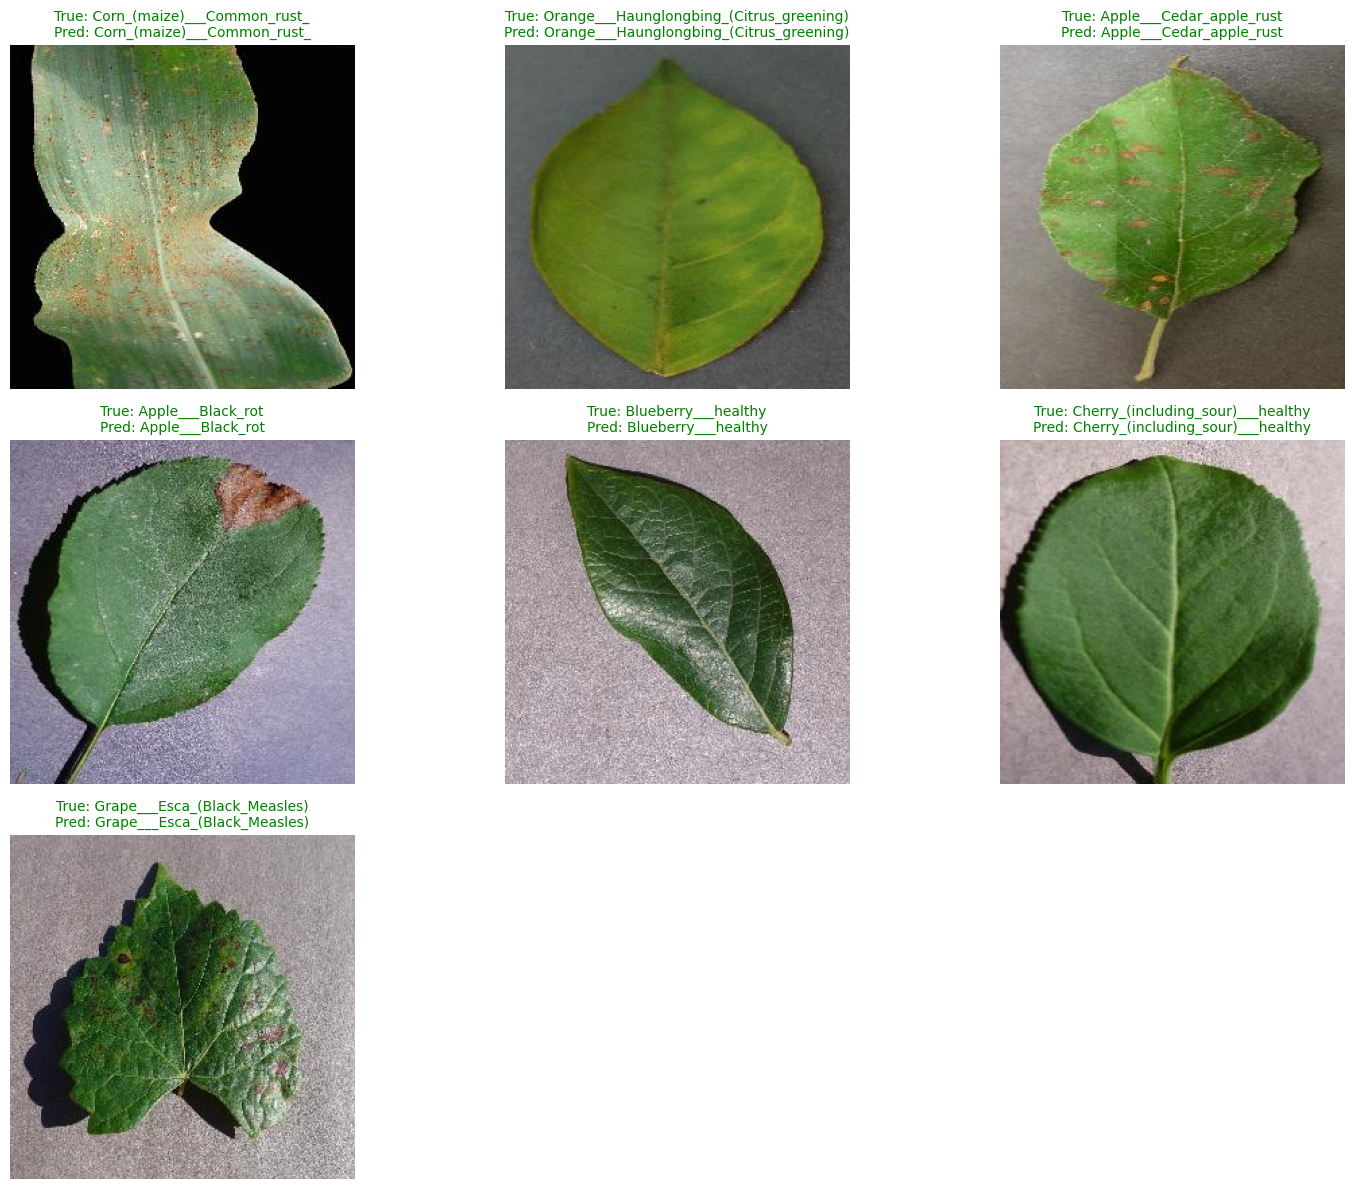

In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# ---- your existing function/model assumed available ----
# predict_class(final_model, image_path=..., class_indices=class_indices)

# Your sample paths
image_paths = [
    "/content/plantvillage dataset/color/Corn_(maize)___Common_rust_/RS_Rust 1568.JPG",
    "/content/plantvillage dataset/color/Orange___Haunglongbing_(Citrus_greening)/005fe5e5-ad80-47c5-9f65-87d17d1532e9___UF.Citrus_HLB_Lab 1383.JPG",
    "/content/plantvillage dataset/color/Apple___Cedar_apple_rust/025b2b9a-0ec4-4132-96ac-7f2832d0db4a___FREC_C.Rust 3655.JPG",
    "/content/plantvillage dataset/color/Apple___Black_rot/0139bc6d-391c-4fd1-bcae-cc74dabfddd7___JR_FrgE.S 2734.JPG",
    "/content/plantvillage dataset/color/Blueberry___healthy/011405e4-a92a-44b6-9f04-10fec28d93f5___RS_HL 2311.JPG",
    "/content/plantvillage dataset/color/Cherry_(including_sour)___healthy/0086a8c7-1440-423e-939d-d0567b1fc4e4___JR_HL 4277.JPG",
    "/content/plantvillage dataset/color/Grape___Esca_(Black_Measles)/00b65fe8-cee1-4b68-8ef4-1211814f2845___FAM_B.Msls 3990.JPG",
]

def infer_true_label_from_path(p):
    """
    Assumes PlantVillage structure:
      .../color/<CLASS_NAME>/<file>.jpg
    True label = the directory name right above the file.
    """
    # Normalize for safety
    p = os.path.normpath(p)
    # Parent directory name is the class
    return os.path.basename(os.path.dirname(p))

# Collect results
results = []
for p in image_paths:
    if not os.path.exists(p):
        results.append({
            "path": p,
            "true": infer_true_label_from_path(p),
            "pred": "<file not found>",
            "exists": False
        })
        continue

    pred_name = predict_class(final_model, image_path=p, class_indices=class_indices)
    true_name = infer_true_label_from_path(p)
    results.append({
        "path": p,
        "true": true_name,
        "pred": pred_name,
        "exists": True
    })

# Print a clean text summary
print("Summary (True vs Pred):")
for r in results:
    status = "✅" if r["exists"] and (r["true"] == r["pred"]) else ("❌" if r["exists"] else "🚫")
    print(f"{status} Image: {r['path']}\n    True: {r['true']}\n    Pred: {r['pred']}\n")

# Show a grid of images with colored titles
valid = [r for r in results if r["exists"]]
if len(valid) > 0:
    cols = 3
    rows = (len(valid) + cols - 1) // cols
    plt.figure(figsize=(5*cols, 4*rows))

    for i, r in enumerate(valid):
        plt.subplot(rows, cols, i+1)
        try:
            img = mpimg.imread(r["path"])
            plt.imshow(img)
            plt.axis("off")
            correct = (r["true"] == r["pred"])
            title_color = "green" if correct else "red"
            plt.title(f"True: {r['true']}\nPred: {r['pred']}", color=title_color, fontsize=10)
        except Exception as e:
            plt.axis("off")
            plt.title(f"Error loading image\n{os.path.basename(r['path'])}", color="red", fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("No valid images found on disk. Double-check your paths (spaces in folder names, etc.).")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive


'archive (2).zip'
 BGE250724060.pdf
'Colab Notebooks'
'csa-vizm-dyh - Jul 11, 2021.pdf'
 GreensboroAdmissionLetter.pdf
 in.gov.abc-ABCID-545852091154.pdf
'rav final res.pdf'
'Rav Pic.jpg'
'ravya passport.pdf'
'WhatsApp Image 2021-05-04 at 10.01.06 AM.jpeg'
